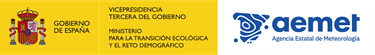

# 6. Trabajar con ficheros de texto

Para abrir el notebook en Colab o Binder pulsa el botón respectivo:

<a target="_blank" href="https://colab.research.google.com/github/alprietoa/pruebas-curso/blob/main/06_Ficheros.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/alprietoa/pruebas-curso.git/HEAD?urlpath=%2Fdoc%2Ftree%2F06_Ficheros.ipynb)


Todo lo que hemos visto hasta ahora no perdura, es decir, una vez cerrado el programa, toda interacción con el usuario no tendrá efecto en las posteriores ejecuciones.

La ruta o *path* de un archivo indica su ubicación en el ordenador y puede ser relativa o absoluta.

## 6.1 Abrir y cerrar un archivo de texto

Esto se puede hacer con la función `open()`, que recibe como parámetros la ruta donde se encuentra el archivo y el modo de apertura.

Después de usar un archivo es importante cerrarlo. La forma más recomendable en Python es utilizar `with`, porque el archivo se cierra automáticamente al terminar el bloque.

Los modos más habituales son:

- `'r'`: solo lectura.
- `'w'`: escritura; crea el archivo o sobrescribe su contenido.
- `'a'`: *append*; añade contenido al final del archivo.

La forma básica de apertura y cierre explícito es:

```python
mi_archivo = open("<nombre del archivo>", "<modo>")
mi_archivo.close()
```

La alternativa recomendada es:

```python
with open("<nombre del archivo>", "<modo>") as mi_archivo:
    # Aquí va la lectura y/o escritura del archivo
    ...
```

## Preparación de los archivos de ejemplo

Para que este notebook sea autocontenido, creamos aquí el archivo `aemet.txt` utilizado en los ejemplos.

In [ ]:
from pathlib import Path

contenido_aemet = """Como Servicio Meteorológico Nacional y Autoridad Meteorológica del Estado,
El objetivo básico de AEMET es contribuir a la protección de vidas y bienes.
A través de la adecuada predicción y vigilancia de fenómenos meteorológicos adversos.
Como soporte a las actividades sociales y económicas en España.
Mediante la prestación de servicios meteorológicos de calidad.
"""

Path("aemet.txt").write_text(contenido_aemet, encoding="utf-8")

print("Archivo creado: aemet.txt")
print()
print(Path("aemet.txt").read_text(encoding="utf-8"))

## 6.2 Leer un archivo de texto

Vamos a abrir un fichero en modo lectura (`'r'`) y a ver distintas formas de acceder a su contenido.

### `readline()`

La función `readline()` lee una línea del archivo cada vez que se llama. El archivo mantiene internamente la posición de lectura, de modo que la siguiente llamada continúa desde donde terminó la anterior.

In [ ]:
mi_archivo = open("aemet.txt", "r", encoding="utf-8")

linea_1 = mi_archivo.readline()
print(linea_1)

linea_2 = mi_archivo.readline()
print(linea_2)

linea_3 = mi_archivo.readline()
print(linea_3)

mi_archivo.close()

En Python 3 es recomendable especificar explícitamente la codificación cuando conocemos la del archivo, por ejemplo `encoding="utf-8"`. Esto permite manejar correctamente caracteres como tildes, `ñ`, etc.

In [ ]:
with open("aemet.txt", "r", encoding="utf-8") as mi_archivo:
    linea_1 = mi_archivo.readline()
    print(linea_1)

    linea_2 = mi_archivo.readline()
    print(linea_2)

    linea_3 = mi_archivo.readline()
    print(linea_3)

### `readlines()`

La función `readlines()` lee todas las líneas restantes del archivo y devuelve una lista de cadenas de texto.

In [ ]:
with open("aemet.txt", "r", encoding="utf-8") as mi_archivo:
    lineas = mi_archivo.readlines()

print(lineas)

Cada elemento de la lista corresponde a una línea del archivo.

>### Ejemplo 1
>
>Imprime en consola, como un solo *string* y sin saltos de línea, el contenido de un archivo `ejemplo.txt` con este contenido:
>
>```text
>Hola ,soy un archivo.
>```
>*Ver la solución →* [ejemplo1.py](06_ficheros/ejemplo1.py)

In [ ]:
# Puede realizar el ejercicio propuesto en esta celda de código:



In [ ]:
from pathlib import Path

Path("ejemplo.txt").write_text(
    "Hola ,\nsoy\nun\narchivo .\n",
    encoding="utf-8"
)

with open("ejemplo.txt", "r", encoding="utf-8") as mi_archivo:
    contenido = mi_archivo.read()

sin_saltos = contenido.replace("\n", " ")
print(sin_saltos)

## 6.3 Escribir un archivo de texto

Para escribir un archivo necesitamos abrirlo en modo escritura.

### Modo `write`

Con el modo `'w'`, Python crea el archivo si no existe. Si ya existe, su contenido anterior se sobrescribe.

La función `write()` recibe la cadena que queremos guardar.

In [ ]:
mi_archivo = open("nombre_del_archivo.txt", "w", encoding="utf-8")
mi_archivo.write("String con contenido a escribir")
mi_archivo.close()

print(Path("nombre_del_archivo.txt").read_text(encoding="utf-8"))

La misma operación puede escribirse de forma más segura utilizando `with`.

In [ ]:
with open("nombre_del_archivo.txt", "w", encoding="utf-8") as mi_archivo:
    mi_archivo.write("String con contenido a escribir")

print(Path("nombre_del_archivo.txt").read_text(encoding="utf-8"))

Veamos un ejemplo con varias líneas.

In [ ]:
with open("archivo.txt", "w", encoding="utf-8") as mi_archivo:
    mi_archivo.write(
        "Escribe esto en el documento\n"
        "Esta va a ser otra línea\n"
        "Y esta otra"
    )

print(Path("archivo.txt").read_text(encoding="utf-8"))

Si volvemos a abrir el mismo archivo en modo `'w'`, su contenido se sobrescribe.

In [ ]:
with open("archivo.txt", "w", encoding="utf-8") as mi_archivo:
    mi_archivo.write("Esto es nuevo")

print(Path("archivo.txt").read_text(encoding="utf-8"))

### Modo `append`

Con el modo `'a'`, Python crea el archivo si no existe. Si ya existe, el nuevo contenido se añade al final en lugar de sobrescribirlo.

In [ ]:
with open("archivo_append.txt", "w", encoding="utf-8") as mi_archivo:
    mi_archivo.write("Primera línea\n")

with open("archivo_append.txt", "a", encoding="utf-8") as mi_archivo:
    mi_archivo.write("Segunda línea\n")

print(Path("archivo_append.txt").read_text(encoding="utf-8"))

Podemos seguir añadiendo contenido al mismo archivo:

In [ ]:
with open("archivo_append.txt", "a", encoding="utf-8") as mi_archivo:
    mi_archivo.write("Esto es nuevo\n")

print(Path("archivo_append.txt").read_text(encoding="utf-8"))

## 6.4 Ejercicios

>### Ejercicio 6.1
>
>Crear un archivo llamado `observaciones.txt` que contendrá una lista de observaciones con los siguientes campos:
>
>- temperatura
>- precipitación
>- humedad
>- presión
>
>Leer cada línea, colocar cada campo en un diccionario y mostrar los datos del diccionario.
>
>*Ver las soluciones →* [observaciones.txt](06_ficheros/observaciones.txt) y [ejercicio61.py](06_ficheros/ejercicio61.py) 

In [ ]:
# Puede realizar el ejercicio propuesto en esta celda de código:



>### Ejercicio 6.2
>
>Realizar un programa que lea del usuario una palabra y busque esa palabra en un archivo de texto llamado `mi_texto.txt`.
>
>El programa debe:
>
>1. Contar cuántas ocurrencias de la palabra hay en el archivo después de leer todo su contenido y mostrar esa cantidad.
>2. Crear otro archivo llamado `resultado.txt` que contenga únicamente las líneas en las que aparece la palabra buscada, indicando al >principio de cada línea su número de línea.
>
>*Ver las soluciones →* [mi_texto.txt](06_ficheros/mi_texto.txt) y [ejercicio62.py](06_ficheros/ejercicio62.py) 

In [ ]:
# Puede realizar el ejercicio propuesto en esta celda de código:

